
## 01MIAR - Actividad Video Valencia Pollution

## NumPy y Pandas

### Objetivos:
- Aplicar diferentes técnicas de tratamiento de estructuras numéricas con Numpy y datos estructurados con Pandas.

### Instrucciones:
- Mantener una estructura limpia, comentando código y secuenciando los apartados con el código correspondiente que resuelva la actividad.
- Como criterio de evaluación se tendrá en cuenta el resultado, la consecución del mismo, estilo, comentarios y adecuación. Siempre será tenido en cuenta cualquier detalle técnico avanzado o no visto en clase relacionado con el tema (explicar el porqué y usabilidad).
- No está permitido compartir los resultados ni el código en ninguno de los foros.
- Revisar los temas así como las sesiones sobre Numpy y Pandas para aplicar dichos contenidos.
- Proponer las respuestas en las celdas a dicho efecto en cada punto, si se necesitan más celdas añadirlas en su sitio correspondiente
- Mostrar de manera clara la respuesta a las preguntas, mediante código

### Entrega:
- Este mismo notebook con las respuetas

### Evaluación
- Esta actividad corresponde con el 10% de la nota final de la asignatura.

### Fecha Realización
- Convocatoria 1 - 30/05/2026 00:00 - 31/05/2026 23:59 (Hora España)

#### Descripción
El conjunto de datos "valencia_pollution_dataset.csv" (fichero disponible adjunto a la actividad) proviene de una descarga de datos del servicio web del ayuntamiento de la ciudad de Valencia de datos abiertos.

Cada estación realiza una serie de mediciones acerca de la calidad del aire, y de ciertas sustancias que se consideran importantes para analizar la contaminación atmosférica en la ciudad.

#### Columnas para trabajar:
- objectid: id de la estación
- nombre: nombre de la estación
- dirección: dirección de la estación
- tipozona: tipo de la zona, urbana o sub urbana
- parámetros: parámetroe medidos
- mediciones: fichero de mediciones
- tipoemisio: tráfico o fondo
- so2: niveles de dióxido de azufre
- no2: niveles de dióxido de nitrogeno
- o3: niveles de ozono
- co: niveles de monóxido de carbono
- pm10: niveles de partículas en suspensión hasta 10um
- pm25: niveles de partículas en suspensión hasta 2,5um
- fecha_carg: timestamp de la actualización de los datos
- calidad_am: estimación de la calidad del aire
- fiwareid: Identificador sensor
- lon: longitud en coordenadas geográficas
- lat: latitud en coordenadas geográficas

In [302]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr # spearman para el ejercicio final

## 01
- Carga de datos de csv (valencia_pollution_dataset.csv) en un DataFrame.
- Mostrar 6 fillas aleatorias
- Mostrar la cantidad de valores nulos por columna

In [303]:
df = pd.read_csv('valencia_pollution_dataset.csv') 
sample = df.sample(n=6) 
print("\nMostrando 6 filas aleatorias")
display(sample)

print("\nMostrando total valores nulos por columna")
null_counts = df.isnull().sum() 
display(null_counts.to_frame(name='Valores Nulos'))


Mostrando 6 filas aleatorias


,objectid,nombre,direccion,tipozona,parametros,mediciones,so2,no2,o3,co,pm10,pm25,tipoemisio,fecha_carg,calidad_am,fiwareid,lon,lat
89,21,Olivereta,OLIVERETA,Urbana,"Óxidos de nitrógeno totales (NOx),Monóxido de ...",NaN,NaN,45.0,NaN,NaN,34.0,15.0,Tráfico,2026-05-28 06:00:00,Razonablemente Buena,A10_OLIVERETA_60m,-0.405923,39.469244
236,14,Boulevar Sur,BULEVARD SUD,Urbana,"Dióxido de azufre (SO2),Ozono,Óxidos de nitróg...",http://mapas.valencia.es/WebsMunicipales/uploa...,1.0,58.0,78.0,NaN,NaN,NaN,Tráfico,2026-05-28 23:00:00,Razonablemente Buena,A02_BULEVARDSUD_60m,-0.396338,39.450396
143,20,Cabanyal,CABANYAL,Urbana,NaN,NaN,NaN,70.0,NaN,NaN,29.0,11.0,Fondo,2026-05-28 10:00:00,Razonablemente Buena,A09_CABANYAL_60m,-0.328535,39.474391
98,15,Molí del Sol,MOLÍ DEL SOL,Suburbana,"Dióxido de azufre (SO2),Monóxido de carbono (C...",http://mapas.valencia.es/WebsMunicipales/uploa...,9.0,36.0,39.0,0.0,22.0,10.0,Tráfico,2026-05-28 06:00:00,Razonablemente Buena,A03_MOLISOL_60m,-0.408810,39.481112
80,22,Patraix,PATRAIX,Urbana,"Óxidos de nitrógeno totales (NOx),Monóxido de ...",NaN,NaN,53.0,NaN,NaN,30.0,14.0,Tráfico,2026-05-28 05:00:00,Razonablemente Buena,A11_PATRAIX_60m,-0.401411,39.459189
82,14,Boulevar Sur,BULEVARD SUD,Urbana,"Dióxido de azufre (SO2),Ozono,Óxidos de nitróg...",http://mapas.valencia.es/WebsMunicipales/uploa...,0.0,45.0,55.0,NaN,NaN,NaN,Tráfico,2026-05-28 05:00:00,Razonablemente Buena,A02_BULEVARDSUD_60m,-0.396338,39.450396



Mostrando total valores nulos por columna


,Valores Nulos
objectid,0
nombre,0
direccion,0
tipozona,0
parametros,26
mediciones,104
so2,130
no2,0
o3,130
co,208


## 02
- ¿Cuantas estaciones diferentes hay?
- ¿Cuantas estaciones cuentan con un sensor de monóxido de carbono (co)?
- ¿Cuantas estaciones cuentan con un sensor ozono (o3)?

In [304]:
# estaciones unicas
num_stations = df['nombre'].nunique()
print("\n- ¿Cuantas estaciones diferentes hay?")
print(f"{num_stations} estaciones")

# estaciones con un sensor de monóxido de carbono (co)
stations_with_co_notNa = df[df['co'].notna()]['nombre'].nunique()  
stations_with_co_valid = df[(df['co'].notna()) & (df['co'] > 0)]['nombre'].nunique()  

print("\n- ¿Cuantas estaciones cuentan con un sensor de monóxido de carbono (co)?")
print(f"{stations_with_co_notNa} estaciones con valores no-nulos (no N/A)")
print(f"{stations_with_co_valid} estaciones con valores válidos (> 0)")
print(f"Nota: Muchos valores son 0, lo que podría indicar sensores 'fantasma'. \n Si se asume solo las estaciones con 'co' válido, ninguna estacion cuenta con sensor 'co'")
print(f"\nEn resumen, {stations_with_co_notNa} estaciones cuentan con un sensor de monóxido de carbono, pero no se reportan valores de 'co' válidos por ninguna estacion")

# estaciones con un sensor ozono (o3)
stations_with_o3 = df[df['o3'].notna()]['nombre'].nunique()
stations_with_o3_valid = df[(df['o3'].notna()) & (df['o3'] > 0)]['nombre'].nunique()  

print("\n- ¿Cuantas estaciones cuentan con un sensor ozono (o3)?")
print(f"{stations_with_o3} estaciones con valores no-nulos (no N/A)")
print(f"{stations_with_o3_valid} estaciones con valores validos (> 0)")
if stations_with_o3 == stations_with_o3_valid:
    print(f"Nota: En este caso, los valores no-nulos coinciden con los valores mayores a cero (o3 > 0)")
print(f"\nEn resumen, {stations_with_o3_valid} estaciones cuentan con un sensor ozono (o3)")


- ¿Cuantas estaciones diferentes hay?
11 estaciones

- ¿Cuantas estaciones cuentan con un sensor de monóxido de carbono (co)?
3 estaciones con valores no-nulos (no N/A)
0 estaciones con valores válidos (> 0)
Nota: Muchos valores son 0, lo que podría indicar sensores 'fantasma'. 
 Si se asume solo las estaciones con 'co' válido, ninguna estacion cuenta con sensor 'co'

En resumen, 3 estaciones cuentan con un sensor de monóxido de carbono, pero no se reportan valores de 'co' válidos por ninguna estacion

- ¿Cuantas estaciones cuentan con un sensor ozono (o3)?
6 estaciones con valores no-nulos (no N/A)
6 estaciones con valores validos (> 0)
Nota: En este caso, los valores no-nulos coinciden con los valores mayores a cero (o3 > 0)

En resumen, 6 estaciones cuentan con un sensor ozono (o3)


## 03
 - Para cada sensor (co, o3, no2, so2, pm10 y pm25) indicar la estación con la media de medición más alta.

In [305]:
sensors = ['co', 'o3', 'no2', 'so2', 'pm10', 'pm25']

# Nombres de columnas para evitar repetición
col_station = 'Estación'
col_promedio = 'Promedio'

# Calcular promedio de cada sensor por estación
station_means = df.groupby('nombre')[sensors].mean()
station_means = station_means.where(station_means > 0) # excluye valores 0 - ejemplo 'co'

def get_max_station(series):
    """
    Encuentra la estación con el valor máximo de un sensor.
    Usa idxmax() para localizar el índice de la estación con máximo valor.
    Retorna 'Sin estación válida' si todos los valores son NaN (ValueError) - guarda dado que sabemos de 'co'.
    """
    try:
        return pd.Series({
            col_station: series.idxmax(skipna=True),
            col_promedio: round(series.max(), 2)
        })
    except ValueError:
        return pd.Series({
            col_station: 'Sin estación válida',
            col_promedio: 'N/A'
        })

results_df = station_means.apply(get_max_station).T
results_df = results_df[[col_station, col_promedio]]
display(results_df)

,Estación,Promedio
co,Sin estación válida,N/A
o3,Viveros,78.92
no2,Patraix,53.0
so2,Molí del Sol,6.12
pm10,Olivereta,33.77
pm25,Olivereta,15.0


## 04
Mostrar en dos gráficos de barras la media de las mediciones de dióxido de nitrógeno (no2) de cada estación agrupando por el tipo de zona (tipozona). Cada gráfico debe mostrar un tipo de emisión distinto (tipoemision).

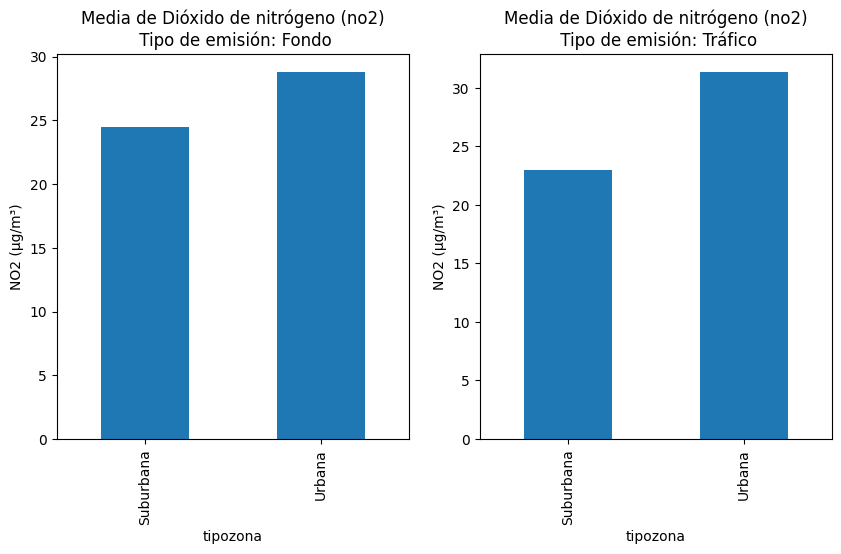

In [306]:
fig, plots = plt.subplots(1, 2, figsize=(10, 5))

for axis, emissionType in zip(plots, sorted(df['tipoemisio'].unique())):
    df[df['tipoemisio'] == emissionType].groupby('tipozona')['no2'].mean().plot(
        kind='bar', ax=axis, title=f'Media de Dióxido de nitrógeno (no2)\n Tipo de emisión: {emissionType}', ylabel='NO2 (µg/m³)'
    )

plt.show()

## 05
Eres un analista de datos y quieres evaluar visualmente si existe una relación entre las mediciones de los sensores (co, o3, no2, so2, pm10 y pm25) y la calidad del aire (calidad_ambiental). ¿Qué visualización propones y porqué?

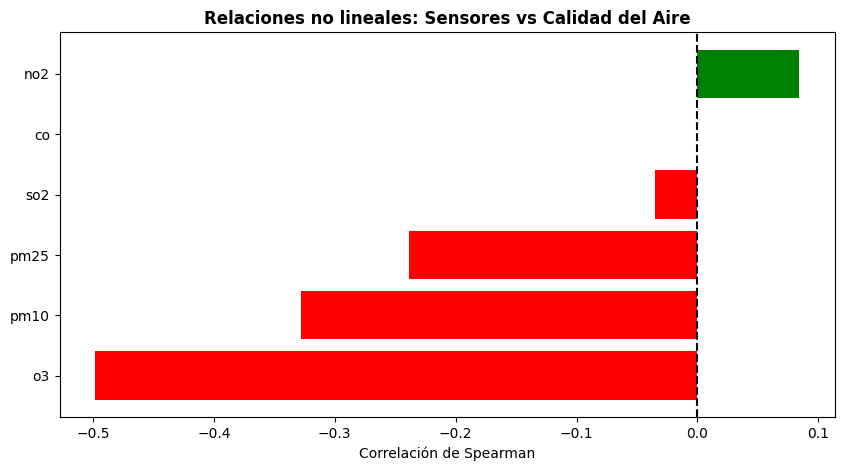

,Sensor,Spearman r,p-value
1,o3,-0.498373,0.00
4,pm10,-0.327539,0.00
5,pm25,-0.238777,0.00
3,so2,-0.035316,0.66
0,co,0.000000,Sin variación
2,no2,0.084399,0.15


In [307]:
# Mapeo de categorías ordinales a valores numéricos asumiendo regular como '0'
quality_map = {
    'Muy Mala': -2,
    'Mala': -1,
    'Regular': 0,
    'Razonablemente Buena': 1,
    'Buena': 2
}

df['quality_numeric'] = df['calidad_am'].map(quality_map)

sensor_columns = ['co', 'o3', 'no2', 'so2', 'pm10', 'pm25']

# Calcular correlación de Spearman para cada sensor
correlations = []
for sensor in sensor_columns:
    valid = df[[sensor, 'quality_numeric']].dropna() # Eliminar filas donde falta el sensor O la calidad - caso del 'co'
    
    if len(valid[sensor].unique()) > 1:  # Verificar si el sensor tiene variación (evitar error si todos los valores son iguales)
        corr, pvalue = spearmanr(valid[sensor], valid['quality_numeric'])
        correlations.append({
            'Sensor': sensor, 
            'Spearman r': corr,  # -1 a 1: -1=correlación negativa perfecta, 1=positiva
            'p-value': f"{pvalue:.2f}"
        })
    else:  # Sensor sin variación (ej: CO siempre 0): no se puede calcular correlación 
        correlations.append({
            'Sensor': sensor, 
            'Spearman r': 0,  # Cambiar a 0 en lugar de np.nan
            'p-value': 'Sin variación'
        })

# Ordenar por correlación (más negativa a más positiva)
results = pd.DataFrame(correlations).sort_values('Spearman r', na_position='last')

# Visualizar con colores: rojo=negativa, verde=positiva, gris=sin datos
fig, ax = plt.subplots(figsize=(10, 5))
colors = []
for val, pval in zip(results['Spearman r'], results['p-value']):
    if pval == 'Sin variación':
        colors.append('gray')  # Sensor sin datos válidos
    elif val < 0:
        colors.append('red') # Más sensor = peor calidad
    else:
        colors.append('green') # Más sensor = mejor calidad

ax.barh(results['Sensor'], results['Spearman r'], color=colors)
ax.set_xlabel('Correlación de Spearman')
ax.set_title('Relaciones no lineales: Sensores vs Calidad del Aire', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--')
plt.show()

display(results)

#### Razonamiento

##### ¿Qué visualización propongo?

Para el análisis de los datos propongo una Correlación de Spearman debido a la **naturaleza de los datos**.

La calidad del aire es una variable **ordinal categórica**, lo que quiere decir que 
"Muy Mala < Mala < Regular < Razonablemente Buena < Buena", **no representa valores continuos reales** (no hay diferencia matemática entre 0 y 1), sino un **rango o escala de orden**.

Los sensores, en cambio, miden variables **continuas** (por ejemplo, el sensor ozono (o3): 52.0, 78.9, 91.0 µg/m³)

Por lo que es necesario relacionar una variable ordinal con variables continuas.

##### ¿Por qué Spearman?

Spearman correlación **usa rangos en lugar de valores reales**. Convierte ambas variables en posiciones (1, 2, 3...) y pregunta: *¿Cuando los sensores suben de rango, sube también la calidad?*

**Ejemplo con O3 (Ozono): basado en los hallazgos de los datos de Valencia**

Cuando O3 sube:
- O3: 37.0 → 78.9 → 117.0 (aumenta)
- Calidad: Buena (2) → Regular (0) → Muy Mala (-2) (disminuye)

Los rangos coinciden en dirección opuesta:
- O3 rangos: 1º → 2º → 3º ↑
- Calidad rangos: 3º → 2º → 1º ↓

**Patrón:** a mayor O3, peor calidad
**Spearman r = -0.498** (correlación negativa moderada-fuerte)
**p-value = 0.00** (estadísticamente significativa)

→ O3 es el mejor predictor de calidad del aire en Valencia

| Sensor | Spearman r | p-value | Significancia |
|--------|-----------|---------|---|
| O3 | -0.498 | 0.00 | Muy significativa |
| PM10 | -0.327 | 0.00 |  Muy significativa |
| PM25 | -0.239 | 0.0002 |  Significativa |
| SO2 | -0.035 | 0.66 |  No significativa |
| NO2 | 0.084 | 0.15 |  No significativa |
| CO | — | — | Sin variación |

**Conclusión:** Los sensores **O3, PM10 y PM25** son los mejores predictores de calidad del aire. O3 destaca como el más fuerte (r = -0.498), indicando que a mayor ozono, peor es la calidad del aire.


##### Correlación ≠ Causación

**Lo que podemos visualizar con la Correlación de Spearman:**
¿Varían juntos? Si o3 sube, ¿tiende la calidad a bajar?

**Lo que NO medimos:**
- ¿O3 causa mala calidad?
- ¿Cuánto cambia exactamente la calidad por O3?

**Por qué esto importa:**
Vemos si existe una **relación real** entre sensor y calidad, sin asumir un mecanismo causal que no conocemos ni podemos validar con los datos disponibles. Por ejemplo, no podemos asumir que existe una relación lineal para una regresión.

---

### ⚠️ Nota de Transparencia
Este análisis fue desarrollado por la autora. Claude AI fue utilizado como herramienta de soporte para optimización de código y mejora de redacción y ortografía. El análisis, decisiones metodológicas e implementación son responsabilidad de la autora.

---